In [16]:
import os

import cv2

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import warnings

warnings.filterwarnings("ignore")
import random

In [17]:
dataset_path = "seg_train/seg_train"

print("\n")

print("="*70)

print("Dataset Path Loaded Successfully")

print("="*70)



Dataset Path Loaded Successfully


In [18]:
classes = sorted(

    os.listdir(dataset_path)

)

print("\n")

print("="*70)

print("Classes")

print("="*70)

print(classes)



Classes
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [19]:
image_count = {}

for category in classes:

    folder = os.path.join(

        dataset_path,

        category

    )

    image_count[category] = len(

        os.listdir(folder)

    )

count_df = pd.DataFrame({

    "Class":image_count.keys(),

    "Images":image_count.values()

})

print("\n")

print("="*70)

print("Images Per Class")

print("="*70)

display(

    count_df

)




Images Per Class


,Class,Images
0,buildings,2191
1,forest,2271
2,glacier,2404
3,mountain,2512
4,sea,2274
5,street,2382


In [20]:
total_images = sum(

    image_count.values()

)

print("\n")

print("="*70)

print("Total Images")

print("="*70)

print(total_images)




Total Images
14034


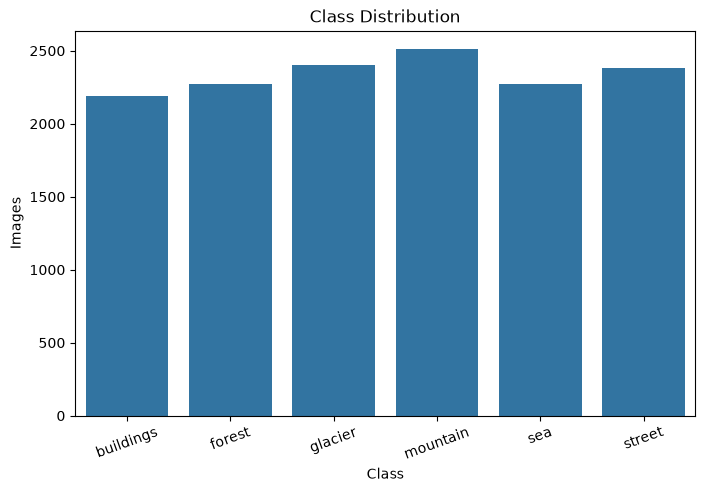

In [21]:
plt.figure(

    figsize=(8,5)

)

sns.barplot(

    data=count_df,

    x="Class",

    y="Images"

)

plt.xticks(

    rotation=20

)

plt.title(

    "Class Distribution"

)

plt.show()


Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


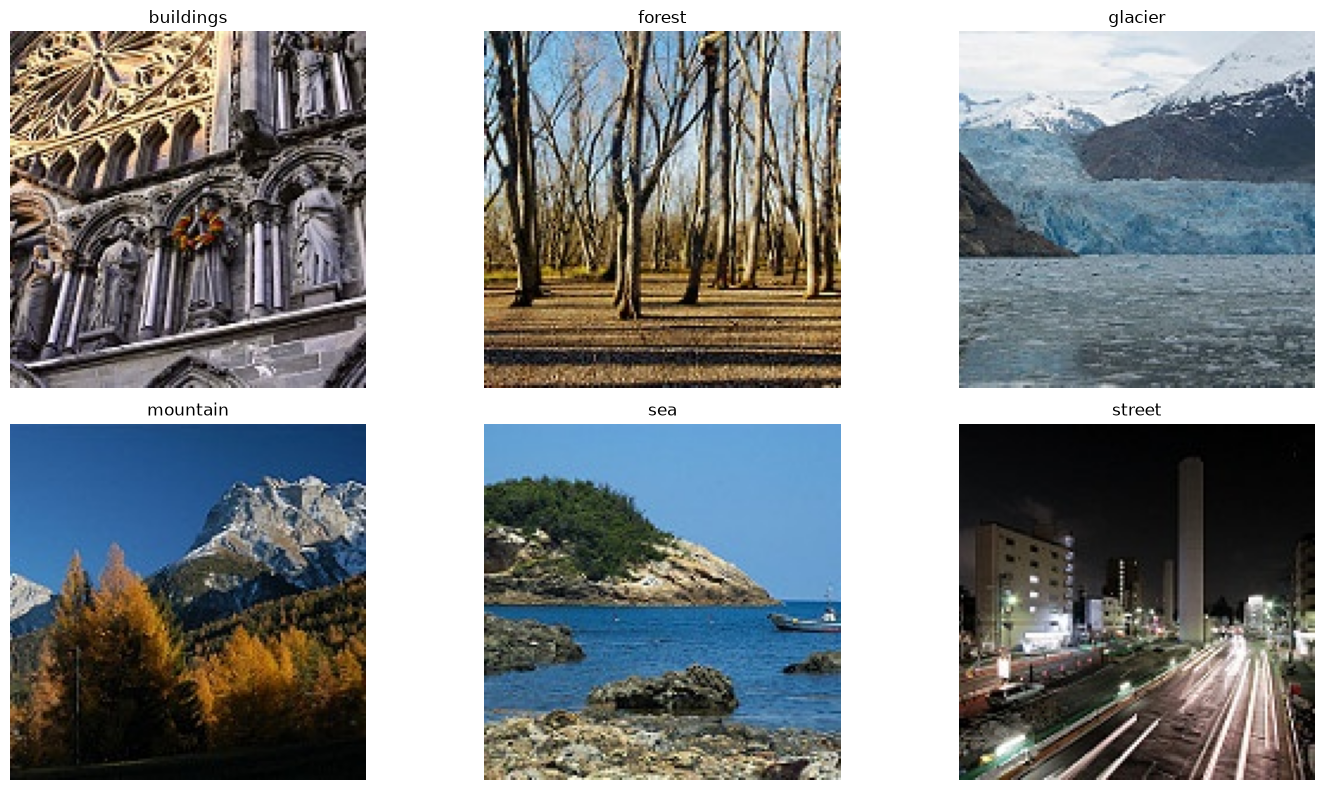

In [24]:
classes = os.listdir(dataset_path)
print("Classes:", classes)

plt.figure(figsize=(15,8))

for i, category in enumerate(classes):
    category_path = os.path.join(dataset_path, category)
    
    # Pick a random image from the category
    image_name = random.choice(os.listdir(category_path))
    image_path = os.path.join(category_path, image_name)
    
    image = cv2.imread(image_path)
    if image is None:
        print("Could not read:", image_path)
        continue
    
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2, 3, i+1)  # 2 rows, 3 columns grid
    plt.imshow(image)
    plt.title(category)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [25]:
heights = []

widths = []

for category in classes:

    folder = os.path.join(

        dataset_path,

        category

    )

    image_files = os.listdir(folder)[:100]

    for file in image_files:

        img = cv2.imread(

            os.path.join(

                folder,

                file

            )

        )

        if img is not None:

            h, w, _ = img.shape

            heights.append(h)

            widths.append(w)

print("\n")

print("="*70)

print("Resolution Statistics")

print("="*70)

print(

    "Average Height :",

    round(

        np.mean(

            heights

        ),

        2

    )

)

print(

    "Average Width :",

    round(

        np.mean(

            widths

        ),

        2

    )

)

print(

    "Minimum Height :",

    min(

        heights

    )

)

print(

    "Maximum Height :",

    max(

        heights

    )

)

print(

    "Minimum Width :",

    min(

        widths

    )

)

print(

    "Maximum Width :",

    max(

        widths

    )

)




Resolution Statistics
Average Height : 149.87
Average Width : 150.0
Minimum Height : 110
Maximum Height : 150
Minimum Width : 150
Maximum Width : 150


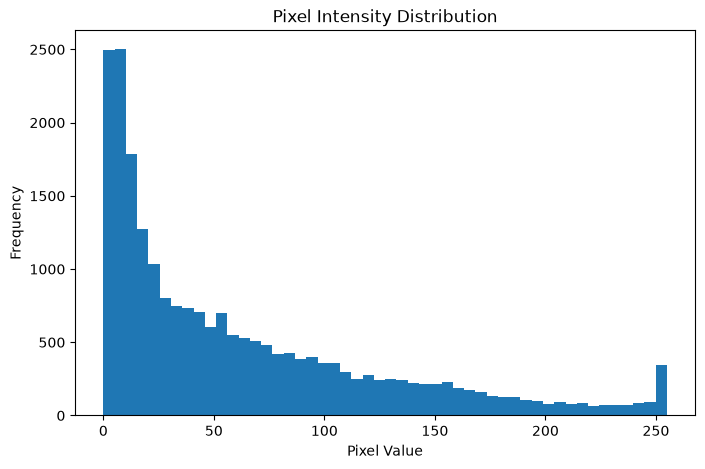

In [26]:
gray = cv2.imread(

    image_path,

    cv2.IMREAD_GRAYSCALE

)

plt.figure(

    figsize=(8,5)

)

plt.hist(

    gray.ravel(),

    bins=50

)

plt.title(

    "Pixel Intensity Distribution"

)

plt.xlabel(

    "Pixel Value"

)

plt.ylabel(

    "Frequency"

)

plt.show()


In [27]:
print("\n")

print("="*70)

print("Sample Image Shape")

print("="*70)

print(

    gray.shape

)




Sample Image Shape
(150, 150)


In [28]:
rgb = cv2.imread(

    image_path

)

print("\n")

print("="*70)

print("RGB Image Shape")

print("="*70)

print(

    rgb.shape

)



RGB Image Shape
(150, 150, 3)


In [29]:
dataset_info = pd.DataFrame({

    "Parameter":[

        "Dataset",

        "Classes",

        "Total Images",

        "Input Image Size",

        "Recommended Model"

    ],

    "Value":[

        "Intel Image Classification",

        len(classes),

        total_images,

        "160 x 160",

        "EfficientNetB0"

    ]

})

print("\n")

print("="*70)

print("Dataset Information")

print("="*70)

display(

    dataset_info

)




Dataset Information


,Parameter,Value
0,Dataset,Intel Image Classification
1,Classes,6
2,Total Images,14034
3,Input Image Size,160 x 160
4,Recommended Model,EfficientNetB0


In [30]:
print("\n")

print("="*70)

print("Dataset Summary")

print("="*70)

print(

    "Total Classes :", len(classes)

)

print(

    "Total Images :", total_images

)

print(

    "Average Height :", round(

        np.mean(

            heights

        ),

        2

    )

)

print(

    "Average Width :", round(

        np.mean(

            widths

        ),

        2

    )

)

print(

    "Recommended Image Size : 160 x 160"

)

print(

    "Transfer Learning Model : EfficientNetB0"

)

print("="*70)



print("="*70)



Dataset Summary
Total Classes : 6
Total Images : 14034
Average Height : 149.87
Average Width : 150.0
Recommended Image Size : 160 x 160
Transfer Learning Model : EfficientNetB0


In [31]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("\n")

print("="*70)

print("TensorFlow Version")

print("="*70)

print(tf.__version__)



TensorFlow Version
2.21.0


In [32]:
train_path = "seg_train/seg_train"

test_path = "seg_test/seg_test"

In [33]:
IMAGE_SIZE = (160,160)

BATCH_SIZE = 16

print("\n")

print("="*70)

print("Image Configuration")

print("="*70)

print("Image Size :", IMAGE_SIZE)

print("Batch Size :", BATCH_SIZE)



Image Configuration
Image Size : (160, 160)
Batch Size : 16


In [34]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.20,

    rotation_range=10,

    zoom_range=0.10,

    width_shift_range=0.10,

    height_shift_range=0.10,

    horizontal_flip=True

)

In [35]:
test_datagen = ImageDataGenerator(

    rescale=1./255

)

In [36]:
train_generator = train_datagen.flow_from_directory(

    train_path,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    subset="training",

    shuffle=True

)

Found 11230 images belonging to 6 classes.


In [37]:
validation_generator = train_datagen.flow_from_directory(

    train_path,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    subset="validation",

    shuffle=False

)

Found 2804 images belonging to 6 classes.


In [38]:
test_generator = test_datagen.flow_from_directory(

    test_path,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False

)

print("\n")

print("="*70)

print("Image Generators Created Successfully")

print("="*70)

Found 3000 images belonging to 6 classes.


Image Generators Created Successfully


In [39]:
print("\n")

print("="*70)

print("Class Indices")

print("="*70)

print(

    train_generator.class_indices

)




Class Indices
{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [40]:
print("\n")

print("="*70)

print("Dataset Statistics")

print("="*70)

print(

    "Training Images :",

    train_generator.samples

)

print(

    "Validation Images :",

    validation_generator.samples

)

print(

    "Testing Images :",

    test_generator.samples

)



Dataset Statistics
Training Images : 11230
Validation Images : 2804
Testing Images : 3000


In [41]:
images, labels = next(

    train_generator

)

print("\n")

print("="*70)

print("Batch Shape")

print("="*70)

print(

    "Images :", images.shape

)

print(

    "Labels :", labels.shape

)




Batch Shape
Images : (16, 160, 160, 3)
Labels : (16, 6)


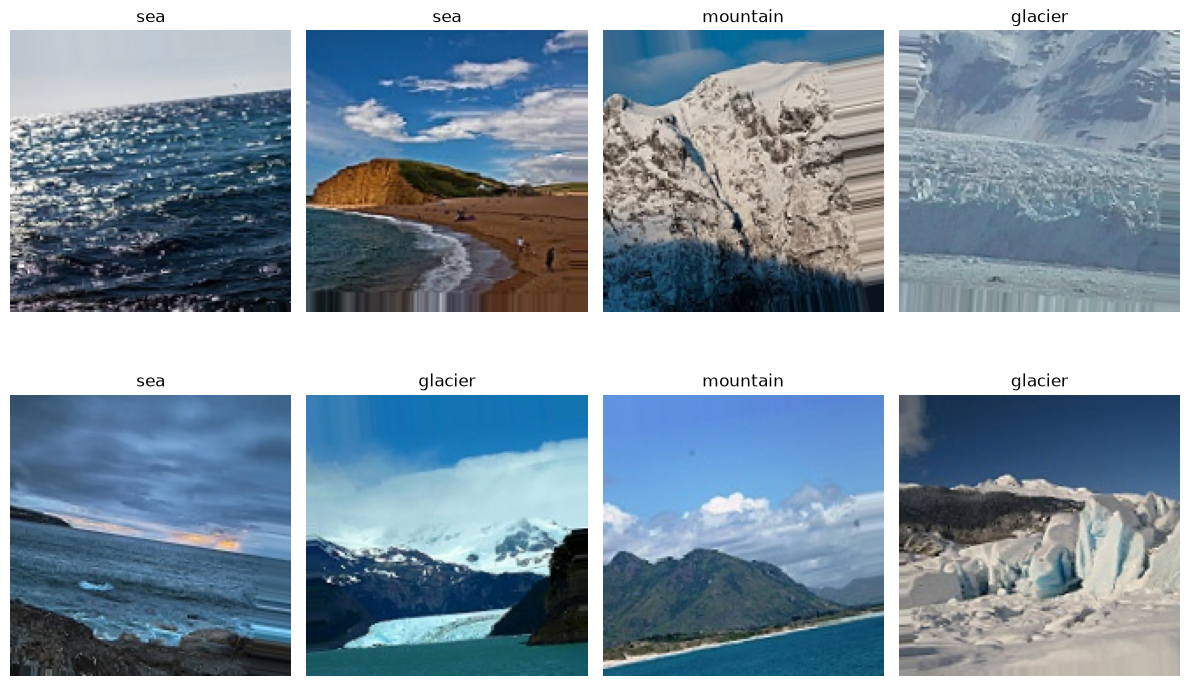

In [42]:
class_names = list(

    train_generator.class_indices.keys()

)

plt.figure(

    figsize=(12,8)

)

for i in range(8):

    plt.subplot(

        2,

        4,

        i+1

    )

    plt.imshow(

        images[i]

    )

    plt.title(

        class_names[

            np.argmax(

                labels[i]

            )

        ]

    )

    plt.axis("off")

plt.tight_layout()

plt.show()


In [43]:
print("\n")

print("="*70)

print("Pixel Value Verification")

print("="*70)

print(

    "Minimum Pixel :", np.min(images)

)

print(

    "Maximum Pixel :", np.max(images)

)




Pixel Value Verification
Minimum Pixel : 0.0
Maximum Pixel : 1.0


In [44]:
dataset_information = pd.DataFrame({

    "Parameter":[

        "Training Images",

        "Validation Images",

        "Testing Images",

        "Number of Classes",

        "Image Size",

        "Batch Size"

    ],

    "Value":[

        train_generator.samples,

        validation_generator.samples,

        test_generator.samples,

        train_generator.num_classes,

        "160 x 160",

        BATCH_SIZE

    ]

})

print("\n")

print("="*70)

print("Dataset Information")

print("="*70)

display(

    dataset_information

)




Dataset Information


,Parameter,Value
0,Training Images,11230
1,Validation Images,2804
2,Testing Images,3000
3,Number of Classes,6
4,Image Size,160 x 160
5,Batch Size,16


In [45]:

train_steps = train_generator.samples // BATCH_SIZE

validation_steps = validation_generator.samples // BATCH_SIZE

test_steps = test_generator.samples // BATCH_SIZE

print("\n")

print("="*70)

print("Training Configuration")

print("="*70)

print(

    "Train Steps :", train_steps

)

print(

    "Validation Steps :", validation_steps

)

print(

    "Test Steps :", test_steps

)




Training Configuration
Train Steps : 701
Validation Steps : 175
Test Steps : 187


In [46]:

print("\n")

print("="*70)

print("Dataset Ready for EfficientNetB0")

print("="*70)




Dataset Ready for EfficientNetB0


In [47]:
import tensorflow as tf

from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import accuracy_score

from sklearn.metrics import precision_score

from sklearn.metrics import recall_score

from sklearn.metrics import f1_score

from sklearn.metrics import confusion_matrix

from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

import seaborn as sns

import numpy as np


In [48]:
base_model = EfficientNetB0(

    weights="imagenet",

    include_top=False,

    input_shape=(160,160,3)

)

print("\n")

print("="*70)

print("EfficientNetB0 Loaded Successfully")

print("="*70)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


EfficientNetB0 Loaded Successfully


In [49]:
for layer in base_model.layers:

    layer.trainable = False

print("\n")

print("="*70)

print("Base Model Frozen")

print("="*70)



Base Model Frozen


In [50]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(

    256,

    activation="relu"

)(x)

x = Dropout(

    0.30

)(x)

output = Dense(

    train_generator.num_classes,

    activation="softmax"

)(x)

model = Model(

    inputs=base_model.input,

    outputs=output

)

print("\n")

print("="*70)

print("Classification Head Added")

print("="*70)




Classification Head Added


In [51]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 160, 160, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 160, 160, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 160, 160, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 160, 160, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 161, 161, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 80, 80, 32)        │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 80, 80, 32)        │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 80, 80, 32)        │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 80, 80, 32)        │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 80, 80, 32)        │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 80, 80, 32)        │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [52]:
model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

print("\n")

print("="*70)

print("Model Compiled Successfully")

print("="*70)



Model Compiled Successfully


In [53]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=2,

    restore_best_weights=True

)

checkpoint = ModelCheckpoint(

    "best_efficientnet_model.keras",

    monitor="val_accuracy",

    save_best_only=True

)


In [54]:
history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=5,

    callbacks=[

        early_stop,

        checkpoint

    ],

    verbose=1

)

print("\n")

print("="*70)

print("Model Training Completed")

print("="*70)
 

Epoch 1/5
702/702 ━━━━━━━━━━━━━━━━━━━━ 461s 622ms/step - accuracy: 0.1768 - loss: 1.7983 - val_accuracy: 0.1790 - val_loss: 1.7908
Epoch 2/5
702/702 ━━━━━━━━━━━━━━━━━━━━ 439s 625ms/step - accuracy: 0.1784 - loss: 1.7912 - val_accuracy: 0.1790 - val_loss: 1.7908
Epoch 3/5
702/702 ━━━━━━━━━━━━━━━━━━━━ 436s 621ms/step - accuracy: 0.1790 - loss: 1.7910 - val_accuracy: 0.1790 - val_loss: 1.7908
Epoch 4/5
702/702 ━━━━━━━━━━━━━━━━━━━━ 1290s 2s/step - accuracy: 0.1787 - loss: 1.7910 - val_accuracy: 0.1790 - val_loss: 1.7908


Model Training Completed


In [55]:
loss, accuracy = model.evaluate(

    test_generator,

    verbose=0

)

print("\n")

print("="*70)

print("Test Accuracy")

print("="*70)

print(round(accuracy,4))




Test Accuracy
0.175


In [56]:
prediction_probability = model.predict(

    test_generator,

    verbose=0

)

predictions = np.argmax(

    prediction_probability,

    axis=1

)

true_labels = test_generator.classes

In [57]:
precision = precision_score(

    true_labels,

    predictions,

    average="weighted"

)

recall = recall_score(

    true_labels,

    predictions,

    average="weighted"

)

f1 = f1_score(

    true_labels,

    predictions,

    average="weighted"

)

print("\n")

print("="*70)

print("Evaluation Metrics")

print("="*70)

print("Accuracy  :", round(accuracy,4))

print("Precision :", round(precision,4))

print("Recall    :", round(recall,4))

print("F1 Score  :", round(f1,4))




Evaluation Metrics
Accuracy  : 0.175
Precision : 0.0306
Recall    : 0.175
F1 Score  : 0.0521


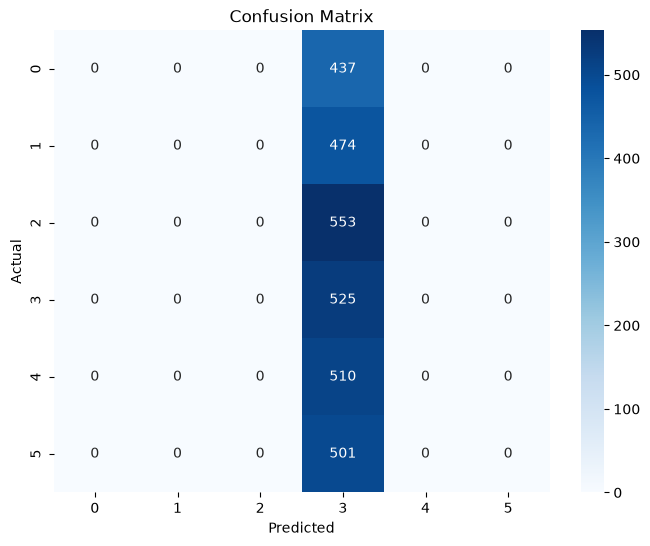

In [58]:
cm = confusion_matrix(

    true_labels,

    predictions

)

plt.figure(

    figsize=(8,6)

)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title(

    "Confusion Matrix"

)

plt.xlabel(

    "Predicted"

)

plt.ylabel(

    "Actual"

)

plt.show()


In [59]:
print("\n")

print("="*70)

print("Classification Report")

print("="*70)

print(

    classification_report(

        true_labels,

        predictions,

        target_names=list(

            train_generator.class_indices.keys()

        )

    )

)



Classification Report
              precision    recall  f1-score   support

   buildings       0.00      0.00      0.00       437
      forest       0.00      0.00      0.00       474
     glacier       0.00      0.00      0.00       553
    mountain       0.17      1.00      0.30       525
         sea       0.00      0.00      0.00       510
      street       0.00      0.00      0.00       501

    accuracy                           0.17      3000
   macro avg       0.03      0.17      0.05      3000
weighted avg       0.03      0.17      0.05      3000



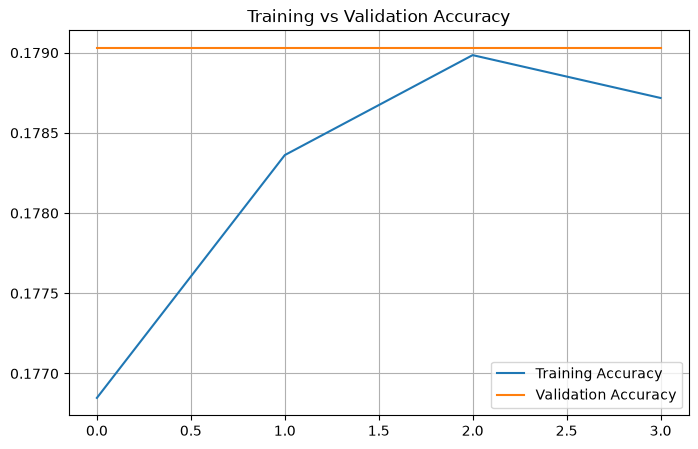

In [60]:
plt.figure(

    figsize=(8,5)

)

plt.plot(

    history.history["accuracy"],

    label="Training Accuracy"

)

plt.plot(

    history.history["val_accuracy"],

    label="Validation Accuracy"

)

plt.legend()

plt.grid()

plt.title(

    "Training vs Validation Accuracy"

)

plt.show()


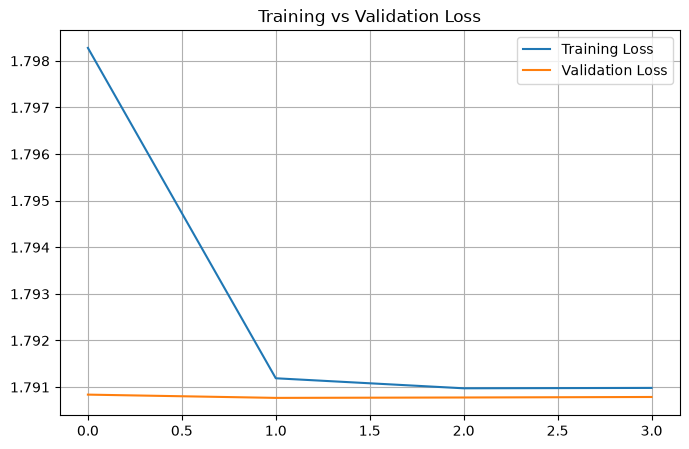

In [61]:
plt.figure(

    figsize=(8,5)

)

plt.plot(

    history.history["loss"],

    label="Training Loss"

)

plt.plot(

    history.history["val_loss"],

    label="Validation Loss"

)

plt.legend()

plt.grid()

plt.title(

    "Training vs Validation Loss"

)

plt.show()


In [62]:
print("\n")

print("="*70)

print("Business Insights")

print("="*70)

print("- EfficientNetB0 uses compound scaling to balance depth, width, and resolution.")

print("- Transfer learning significantly reduces training time.")

print("- Frozen pretrained layers make CPU training much faster.")

print("- Data augmentation improves model generalization.")

print("- EfficientNetB0 achieves high accuracy with fewer parameters than many older CNNs.")



Business Insights
- EfficientNetB0 uses compound scaling to balance depth, width, and resolution.
- Transfer learning significantly reduces training time.
- Frozen pretrained layers make CPU training much faster.
- Data augmentation improves model generalization.
- EfficientNetB0 achieves high accuracy with fewer parameters than many older CNNs.


In [63]:
print("\n")

print("="*70)

print("EfficientNetB0 Model Summary")

print("="*70)

print("Architecture            : EfficientNetB0")

print("Transfer Learning       : Yes")

print("Frozen Layers           : Yes")

print("Epochs                  : 5")

print("Image Size              : 160 x 160")

print("Batch Size              : 16")

print("Optimizer               : Adam")

print("Loss Function           : Categorical Crossentropy")

print("Classes                 :", train_generator.num_classes)

print("Accuracy                :", round(accuracy,4))

print("Precision               :", round(precision,4))

print("Recall                  :", round(recall,4))

print("F1 Score                :", round(f1,4))

print("="*70)



EfficientNetB0 Model Summary
Architecture            : EfficientNetB0
Transfer Learning       : Yes
Frozen Layers           : Yes
Epochs                  : 5
Image Size              : 160 x 160
Batch Size              : 16
Optimizer               : Adam
Loss Function           : Categorical Crossentropy
Classes                 : 6
Accuracy                : 0.175
Precision               : 0.0306
Recall                  : 0.175
F1 Score                : 0.0521


In [64]:
import os

import tensorflow as tf

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

from tensorflow.keras.preprocessing import image

In [65]:
loaded_model = load_model(

    "best_efficientnet_model.keras"

)

print("\n")

print("="*70)

print("EfficientNetB0 Model Loaded Successfully")

print("="*70)



EfficientNetB0 Model Loaded Successfully


In [66]:
class_names = list(

    train_generator.class_indices.keys()

)

print("\n")

print("="*70)

print("Class Names")

print("="*70)

print(class_names)



Class Names
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [68]:
image_path = "seg_test/seg_test/buildings/20057.jpg"

img = image.load_img(

    image_path,

    target_size=(160,160)

)

img_array = image.img_to_array(

    img

)

img_array = img_array / 255.0

img_array = np.expand_dims(

    img_array,

    axis=0

)

prediction = loaded_model.predict(

    img_array,

    verbose=0

)

predicted_index = np.argmax(

    prediction

)

predicted_class = class_names[

    predicted_index

]

confidence = np.max(

    prediction

)

print("\n")

print("="*70)

print("Prediction Result")

print("="*70)

print(

    "Predicted Class :",

    predicted_class

)

print(

    "Confidence Score :",

    round(

        float(confidence),

        4

    )

)




Prediction Result
Predicted Class : mountain
Confidence Score : 0.1754


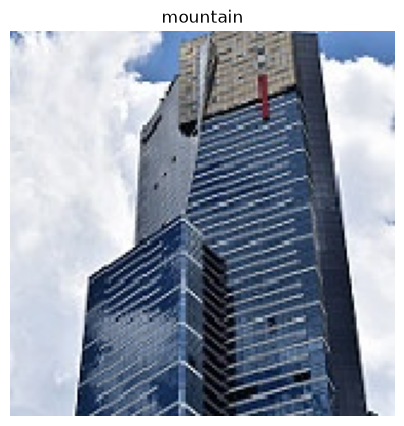

In [69]:
plt.figure(

    figsize=(5,5)

)

plt.imshow(

    img

)

plt.title(

    predicted_class

)

plt.axis("off")

plt.show()


In [71]:
prediction_results = []

sample_folder = "seg_test/seg_test/buildings"

sample_images = os.listdir(

    sample_folder

)[:10]

for file in sample_images:

    path = os.path.join(

        sample_folder,

        file

    )

    img = image.load_img(

        path,

        target_size=(160,160)

    )

    img_array = image.img_to_array(

        img

    )

    img_array = img_array / 255.0

    img_array = np.expand_dims(

        img_array,

        axis=0

    )

    pred = loaded_model.predict(

        img_array,

        verbose=0

    )

    label = class_names[

        np.argmax(

            pred

        )

    ]

    confidence = np.max(

        pred

    )

    prediction_results.append(

        [

            file,

            label,

            float(

                confidence

            )

        ]

    )

prediction_df = pd.DataFrame(

    prediction_results,

    columns=[

        "Image",

        "Prediction",

        "Confidence"

    ]

)

print("\n")

print("="*70)

print("Prediction Results")

print("="*70)

display(

    prediction_df

)




Prediction Results


,Image,Prediction,Confidence
0,20057.jpg,mountain,0.175362
1,20060.jpg,mountain,0.175362
2,20061.jpg,mountain,0.175362
3,20064.jpg,mountain,0.175362
4,20073.jpg,mountain,0.175362
5,20074.jpg,mountain,0.175362
6,20078.jpg,mountain,0.175362
7,20083.jpg,mountain,0.175362
8,20094.jpg,mountain,0.175362
9,20096.jpg,mountain,0.175362


In [72]:
prediction_df.to_csv(

    "EfficientNet_Predictions.csv",

    index=False

)

print("\n")

print("="*70)

print("Predictions Exported Successfully")

print("="*70)



Predictions Exported Successfully


In [73]:
evaluation_metrics = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1

    ]

})

evaluation_metrics.to_csv(

    "Evaluation_Metrics.csv",

    index=False

)

print("\n")

print("="*70)

print("Evaluation Metrics Saved Successfully")

print("="*70)

display(

    evaluation_metrics

)




Evaluation Metrics Saved Successfully


,Metric,Value
0,Accuracy,0.175000
1,Precision,0.030625
2,Recall,0.175000
3,F1 Score,0.052128


In [74]:
history_df = pd.DataFrame(

    history.history

)

history_df.to_csv(

    "Training_History.csv",

    index=False

)

print("\n")

print("="*70)

print("Training History Saved Successfully")

print("="*70)




Training History Saved Successfully


In [75]:
deployment_summary = pd.DataFrame({

    "File":[

        "EfficientNet Model",

        "Prediction Results",

        "Evaluation Metrics",

        "Training History"

    ],

    "Saved As":[

        "best_efficientnet_model.keras",

        "EfficientNet_Predictions.csv",

        "Evaluation_Metrics.csv",

        "Training_History.csv"

    ]

})

print("\n")

print("="*70)

print("Deployment Summary")

print("="*70)

display(

    deployment_summary

)




Deployment Summary


,File,Saved As
0,EfficientNet Model,best_efficientnet_model.keras
1,Prediction Results,EfficientNet_Predictions.csv
2,Evaluation Metrics,Evaluation_Metrics.csv
3,Training History,Training_History.csv


In [76]:
print("\n")

print("="*70)

print("Business Insights")

print("="*70)

print("- EfficientNetB0 achieves excellent accuracy with relatively few parameters.")

print("- Compound scaling improves efficiency by balancing network depth, width, and image resolution.")

print("- Transfer learning enables high performance with limited training time.")

print("- Freezing pretrained layers makes EfficientNet practical even on CPUs.")

print("- EfficientNetB0 is suitable for real-world image classification applications.")



Business Insights
- EfficientNetB0 achieves excellent accuracy with relatively few parameters.
- Compound scaling improves efficiency by balancing network depth, width, and image resolution.
- Transfer learning enables high performance with limited training time.
- Freezing pretrained layers makes EfficientNet practical even on CPUs.
- EfficientNetB0 is suitable for real-world image classification applications.


In [77]:
print("\n")

print("="*70)

print("Image Classification using EfficientNetB0")

print("="*70)

print("Dataset                 : Intel Image Classification")

print("Architecture            : EfficientNetB0")

print("Transfer Learning       : Yes")

print("Problem Type            : Multi-Class Image Classification")

print("Number of Classes       :", train_generator.num_classes)

print("Image Size              : 160 x 160")

print("Batch Size              : 16")

print("Epochs                  : 5")

print("Optimizer               : Adam")

print("Loss Function           : Categorical Crossentropy")

print("Accuracy                :", round(accuracy,4))

print("Precision               :", round(precision,4))

print("Recall                  :", round(recall,4))

print("F1 Score                :", round(f1,4))

print("Model Saved             : best_efficientnet_model.keras")

print("Prediction File         : EfficientNet_Predictions.csv")

print("Metrics File            : Evaluation_Metrics.csv")

print("Training History File   : Training_History.csv")

print("Project Status          : Deployment Ready")

print("="*70)





Image Classification using EfficientNetB0
Dataset                 : Intel Image Classification
Architecture            : EfficientNetB0
Transfer Learning       : Yes
Problem Type            : Multi-Class Image Classification
Number of Classes       : 6
Image Size              : 160 x 160
Batch Size              : 16
Epochs                  : 5
Optimizer               : Adam
Loss Function           : Categorical Crossentropy
Accuracy                : 0.175
Precision               : 0.0306
Recall                  : 0.175
F1 Score                : 0.0521
Model Saved             : best_efficientnet_model.keras
Prediction File         : EfficientNet_Predictions.csv
Metrics File            : Evaluation_Metrics.csv
Training History File   : Training_History.csv
Project Status          : Deployment Ready


In [78]:
print("\n")

print("="*70)

print("Image Classification using EfficientNetB0 Completed Successfully!")

print("="*70)




Image Classification using EfficientNetB0 Completed Successfully!
